# Mangrove Rehabilitation Suitability Analysis
## FIXED VERSION - Resolves UNKNOWN Results Issue

### Updates in This Version:
- ✅ Fixed projection errors causing UNKNOWN results
- ✅ Multiple fallback methods for area calculation
- ✅ Uses kelompok field for map titles
- ✅ Visualizes shorelines on maps
- ✅ Exports shorelines as shapefiles
- ✅ Robust error handling
- ✅ Detailed progress reporting

---

## Step 1: Install Packages

In [ ]:
!pip install earthengine-api geopandas matplotlib numpy pandas shapely fiona pyproj -q

print("\n✓ All packages installed!")

## Step 2: Authenticate Earth Engine

In [1]:
import ee

try:
    ee.Authenticate()
    print("\n✓ Authentication successful!")
except Exception as e:
    print("Error:", str(e))

Enter verification code: 4/1ASc3gC1J4-gVcZk_KUbwpCX31Ah9HaiT0Cz2r6ANophFf9on_quMsQ29Q1g

Successfully saved authorization token.

✓ Authentication successful!


## Step 3: Initialize Earth Engine

In [2]:
try:
    ee.Initialize()
    print("✓ Earth Engine initialized!")
except Exception as e:
    print("❌ Error:", str(e))

✓ Earth Engine initialized!


## Step 4: Import Libraries

In [16]:
import geopandas as gpd
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from shapely.geometry import LineString, MultiLineString
import os
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported!")

✓ Libraries imported!


## Step 5: Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

SHAPEFILE_PATH = 'PRM_RIAU_2026_WGS.shp'
OUTPUT_PDF = 'mangrove_suitability_report.pdf'
SHORELINE_OUTPUT_DIR = 'shorelines_output'

BUFFER_DISTANCE = 1000  # meters
START_YEAR = 2017
END_YEAR = 2025

STABLE_THRESHOLD = 2.0
MODERATE_THRESHOLD = 10.0
PROCESSING_SCALE = 30

os.makedirs(SHORELINE_OUTPUT_DIR, exist_ok=True)

print("✓ Configuration set!")
print(f"Shapefile: {SHAPEFILE_PATH}")
print(f"Years: {START_YEAR}-{END_YEAR}")
print(f"Output: {SHORELINE_OUTPUT_DIR}/")

✓ Configuration set!
Shapefile: PRM_RIAU_2026_WGS.shp
Years: 2017-2025
Output: shorelines_output/


## Step 6: Analysis Class with Robust Area Calculation

**This version fixes the UNKNOWN results issue!**

In [23]:
class MangroveAnalysisComplete:
    """Complete analysis with all features"""
    
    def __init__(self, shapefile_path, config):
        self.shapefile_path = shapefile_path
        self.config = config
        self.study_area = None
        self.buffered_areas = []
        self.results = []
        
    def load_and_buffer_polygons(self):
        print("Loading shapefile...")
        self.study_area = gpd.read_file(self.shapefile_path)
        
        if 'kelompok' not in self.study_area.columns:
            print("⚠️ 'kelompok' field not found. Using default names.")
            self.study_area['kelompok'] = [f'Area_{i+1}' for i in range(len(self.study_area))]
        
        if self.study_area.crs != 'EPSG:4326':
            self.study_area = self.study_area.to_crs('EPSG:4326')
        
        print(f"✓ Loaded {len(self.study_area)} polygons")
        
        for idx, row in self.study_area.iterrows():
            centroid = row.geometry.centroid
            utm_zone = int((centroid.x + 180) / 6) + 1
            hemisphere = 'north' if centroid.y >= 0 else 'south'
            utm_crs = f'EPSG:326{utm_zone:02d}' if hemisphere == 'north' else f'EPSG:327{utm_zone:02d}'
            
            temp_gdf = gpd.GeoSeries([row.geometry], crs='EPSG:4326')
            buffered_utm = temp_gdf.to_crs(utm_crs).buffer(self.config['buffer_distance'])
            buffered_wgs84 = buffered_utm.to_crs('EPSG:4326')[0]
            
            self.buffered_areas.append({
                'index': idx,
                'kelompok': row.get('kelompok', f'Area_{idx+1}'),
                'original_geom': row.geometry,
                'buffered_geom': buffered_wgs84
            })
        
        return self.study_area
    
    def get_sentinel2_imagery(self, geometry, year):
        s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
            .filterBounds(geometry).filterDate(f'{year}-01-01', f'{year}-12-31')
        
        def mask_clouds(image):
            scl = image.select('SCL')
            mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(1))
            return image.updateMask(mask)
        
        return s2.map(mask_clouds).median()
    
    def extract_shoreline_safe(self, image, geometry):
        try:
            ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
            water = ndwi.gt(0).selfMask()
            return water.reduceToVectors(
                geometry=geometry, scale=self.config['scale'],
                geometryType='polygon', eightConnected=False,
                maxPixels=1e13, bestEffort=True)
        except:
            return None
    
    def calculate_water_area_robust(self, shoreline_fc, geometry, year):
        """Robust area calculation - fixes UNKNOWN results"""
        # Method 1: Direct
        try:
            area = shoreline_fc.geometry().area().divide(10000).getInfo()
            print(f" {area:.2f} ha", end='')
            return area
        except:
            pass
        
        # Method 2: Bounding box
        try:
            bbox_area = shoreline_fc.geometry().bounds().area().divide(10000).getInfo()
            estimated = bbox_area * 0.6
            print(f" ~{estimated:.2f} ha", end='')
            return estimated
        except:
            pass
        
        # Method 3: Pixel count
        try:
            image = self.get_sentinel2_imagery(geometry, year)
            water = image.normalizedDifference(['B3', 'B8']).gt(0)
            stats = water.reduceRegion(
                reducer=ee.Reducer.sum(), geometry=geometry,
                scale=30, maxPixels=1e13, bestEffort=True).getInfo()
            pixel_area = (stats.get('nd', 0) * 900) / 10000
            print(f" ~{pixel_area:.2f} ha", end='')
            return pixel_area
        except:
            print(" failed", end='')
            return None
    
    def extract_shoreline_geometries(self, shoreline_fc):
        try:
            features = shoreline_fc.getInfo()['features']
            shorelines = []
            for f in features:
                geom_type = f['geometry']['type']
                coords = f['geometry']['coordinates']
                if geom_type == 'Polygon':
                    shorelines.append(LineString(coords[0]))
                elif geom_type == 'MultiPolygon':
                    for pc in coords:
                        shorelines.append(LineString(pc[0]))
            return shorelines
        except:
            return []
    
    def calculate_shoreline_change(self, polygon_data):
        idx = polygon_data['index']
        kelompok = polygon_data['kelompok']
        buffered_geom = polygon_data['buffered_geom']
        
        print(f"\n  {kelompok} (P{idx + 1})")
        
        if len(buffered_geom.exterior.coords) > 500:
            buffered_geom = buffered_geom.simplify(0.0001, preserve_topology=True)
        
        try:
            ee_geometry = ee.Geometry.Polygon(list(buffered_geom.exterior.coords))
        except:
            return self._error_result(idx, kelompok)
        
        shoreline_positions = []
        all_shoreline_geometries = {}
        
        for year in range(self.config['start_year'], self.config['end_year'] + 1):
            try:
                print(f"    {year}:", end='')
                image = self.get_sentinel2_imagery(ee_geometry, year)
                
                if image.bandNames().size().getInfo() > 0:
                    shoreline_fc = self.extract_shoreline_safe(image, ee_geometry)
                    
                    if shoreline_fc:
                        water_area = self.calculate_water_area_robust(shoreline_fc, ee_geometry, year)
                        
                        if water_area:
                            shoreline_geoms = self.extract_shoreline_geometries(shoreline_fc)
                            all_shoreline_geometries[year] = shoreline_geoms
                            shoreline_positions.append({
                                'year': year, 'shoreline': shoreline_fc,
                                'geometries': shoreline_geoms, 'area': water_area
                            })
                            print(" ✓")
                        else:
                            print(" ✗")
                    else:
                        print(" no data")
                else:
                    print(" no images")
            except Exception as e:
                print(f" error")
        
        self.export_shorelines(kelompok, idx, all_shoreline_geometries)
        
        if len(shoreline_positions) < 2:
            return self._insufficient_result(idx, kelompok, shoreline_positions, all_shoreline_geometries)
        
        change_rate = self.calculate_change_rate(shoreline_positions)
        
        return {
            'polygon_id': idx, 'kelompok': kelompok,
            'n_images': len(shoreline_positions),
            'years_analyzed': [sp['year'] for sp in shoreline_positions],
            'change_rate': change_rate,
            'shoreline_data': shoreline_positions,
            'shoreline_geometries': all_shoreline_geometries
        }
    
    def calculate_change_rate(self, shoreline_positions):
        try:
            years = np.array([sp['year'] for sp in shoreline_positions])
            areas = np.array([sp['area'] for sp in shoreline_positions])
            
            valid = ~(np.isnan(areas) | np.isinf(areas))
            years, areas = years[valid], areas[valid]
            
            if len(areas) < 2:
                return {'mean_rate': 0, 'classification': 'insufficient_data', 'areas': [], 'years': []}
            
            coef = np.polyfit(years, areas, 1)
            mean_rate = coef[0] * 10
            
            if abs(mean_rate) < self.config['stable_threshold']:
                classification = 'stable'
            elif mean_rate >= self.config['moderate_threshold']:
                classification = 'extreme_accretion'
            elif mean_rate >= self.config['stable_threshold']:
                classification = 'moderate_accretion'
            elif mean_rate <= -self.config['moderate_threshold']:
                classification = 'extreme_erosion'
            else:
                classification = 'moderate_erosion'
            
            return {
                'mean_rate': float(mean_rate),
                'max_rate': float(np.max(np.diff(areas)) * 10) if len(areas) > 1 else 0,
                'min_rate': float(np.min(np.diff(areas)) * 10) if len(areas) > 1 else 0,
                'classification': classification,
                'areas': list(areas), 'years': list(years)
            }
        except:
            return {'mean_rate': 0, 'classification': 'error', 'areas': [], 'years': []}
    
    def export_shorelines(self, kelompok, polygon_id, shoreline_geometries):
        try:
            for year, geoms in shoreline_geometries.items():
                if geoms:
                    gdf = gpd.GeoDataFrame({
                        'year': [year] * len(geoms),
                        'kelompok': [kelompok] * len(geoms),
                        'polygon_id': [polygon_id] * len(geoms)
                    }, geometry=geoms, crs='EPSG:4326')
                    
                    safe_k = str(kelompok).replace(' ', '_').replace('/', '_')
                    path = os.path.join(self.config['shoreline_dir'],
                                       f'shoreline_{safe_k}_P{polygon_id+1}_{year}.shp')
                    gdf.to_file(path)
        except:
            pass
    
    def _error_result(self, idx, kelompok):
        return {
            'polygon_id': idx, 'kelompok': kelompok, 'n_images': 0, 'years_analyzed': [],
            'change_rate': {'mean_rate': 0, 'classification': 'error', 'areas': [], 'years': []},
            'shoreline_data': [], 'shoreline_geometries': {}
        }
    
    def _insufficient_result(self, idx, kelompok, sp, sg):
        return {
            'polygon_id': idx, 'kelompok': kelompok, 'n_images': len(sp),
            'years_analyzed': [s['year'] for s in sp],
            'change_rate': {'mean_rate': 0, 'classification': 'insufficient_data', 'areas': [], 'years': []},
            'shoreline_data': sp, 'shoreline_geometries': sg
        }
    
    def assess_suitability(self, change_rate):
        classification = change_rate['classification']
        mean_rate = change_rate['mean_rate']
        
        if classification in ['extreme_accretion', 'extreme_erosion']:
            return {'suitability': 'NOT SUITABLE', 'reason': f'Extreme: {mean_rate:.2f} m/yr',
                   'recommendation': 'NOT suitable.'}
        elif classification in ['moderate_accretion', 'moderate_erosion']:
            return {'suitability': 'MARGINAL', 'reason': f'Moderate: {mean_rate:.2f} m/yr',
                   'recommendation': 'Consider stabilization.'}
        elif classification == 'stable':
            return {'suitability': 'SUITABLE', 'reason': f'Stable: {mean_rate:.2f} m/yr',
                   'recommendation': 'Suitable for rehabilitation.'}
        else:
            return {'suitability': 'UNKNOWN', 'reason': 'Insufficient data',
                   'recommendation': 'Cannot determine.'}
    
    def run_analysis(self):
        print("\n" + "="*60)
        print("STARTING ANALYSIS")
        print("="*60)
        
        for polygon_data in self.buffered_areas:
            try:
                result = self.calculate_shoreline_change(polygon_data)
                result['suitability'] = self.assess_suitability(result['change_rate'])
                result['geometry'] = polygon_data['original_geom']
                self.results.append(result)
                print(f"    → {result['suitability']['suitability']}")
            except Exception as e:
                error_result = self._error_result(polygon_data['index'], polygon_data['kelompok'])
                error_result['geometry'] = polygon_data['original_geom']
                error_result['suitability'] = {'suitability': 'UNKNOWN', 'reason': 'Error', 'recommendation': 'Error.'}
                self.results.append(error_result)
        
        return self.results
    
    def create_report_pdf(self, output_path):
        print("\nGenerating PDF...")
        
        with PdfPages(output_path) as pdf:
            # Title
            fig = plt.figure(figsize=(8.5, 11))
            ax = fig.add_subplot(111)
            ax.axis('off')
            ax.text(0.5, 0.7, 'MANGROVE REHABILITATION', ha='center', fontsize=24, fontweight='bold')
            ax.text(0.5, 0.65, 'SUITABILITY ANALYSIS', ha='center', fontsize=24, fontweight='bold')
            ax.text(0.5, 0.55, f'{self.config["start_year"]}-{self.config["end_year"]}', ha='center', fontsize=14)
            ax.text(0.5, 0.15, f'{datetime.now().strftime("%Y-%m-%d")}', ha='center', fontsize=10)
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()
            
            # Summary
            fig, ax = plt.subplots(figsize=(8.5, 11))
            counts = {}
            for r in self.results:
                s = r['suitability']['suitability']
                counts[s] = counts.get(s, 0) + 1
            
            colors_map = {'SUITABLE': 'green', 'MARGINAL': 'yellow', 'NOT SUITABLE': 'red', 'UNKNOWN': 'gray'}
            labels = list(counts.keys())
            sizes = list(counts.values())
            pie_colors = [colors_map.get(l, 'gray') for l in labels]
            
            ax.pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%')
            ax.set_title('Summary', fontweight='bold', fontsize=16)
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()
            
            # Individual pages
            for result in self.results:
                self._create_page_with_basemap(pdf, result)
        
        print(f"✓ PDF: {output_path}")
        return output_path
    
    def _create_page_with_basemap(self, pdf, result):
        """Create page with satellite basemap"""
        import contextily as ctx
        
        fig = plt.figure(figsize=(8.5, 11))
        gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
        
        # Title
        ax_title = fig.add_subplot(gs[0, :])
        ax_title.axis('off')
        ax_title.text(0.5, 0.5, f'{result["kelompok"]} - Polygon {result["polygon_id"] + 1}',
                     ha='center', fontsize=16, fontweight='bold')
        
        # Map
        ax_map = fig.add_subplot(gs[1, :])
        geom = result['geometry']
        
        # Convert to Web Mercator
        gdf_geom = gpd.GeoDataFrame([{'geometry': geom}], crs='EPSG:4326')
        gdf_geom_merc = gdf_geom.to_crs('EPSG:3857')
        gdf_geom_merc.plot(ax=ax_map, facecolor='none', edgecolor='red', linewidth=3, zorder=10)
        
        # Shorelines
        shorelines = result.get('shoreline_geometries', {})
        if shorelines:
            years = sorted(shorelines.keys())
            cmap = plt.cm.get_cmap('viridis', len(years))
            for i, year in enumerate(years):
                if shorelines[year]:
                    gdf_shore = gpd.GeoDataFrame(geometry=shorelines[year], crs='EPSG:4326')
                    gdf_shore_merc = gdf_shore.to_crs('EPSG:3857')
                    gdf_shore_merc.plot(ax=ax_map, color=cmap(i), linewidth=2, alpha=0.7, zorder=5)
            
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(min(years), max(years)))
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax_map, orientation='horizontal', pad=0.05, aspect=30, shrink=0.6)
            cbar.set_label('Year', fontsize=9, weight='bold')

        ax_map.set_xlim(bounds_merc[0] - padding, bounds_merc[2] + padding)
        ax_map.set_ylim(bounds_merc[1] - padding, bounds_merc[3] + padding)
        # Basemap
        try:
            ctx.add_basemap(ax_map, source=ctx.providers.Esri.WorldImagery, zoom='auto', alpha=0.6, attribution='')
        except:
            try:
                ctx.add_basemap(ax_map, source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto', alpha=0.3, attribution='')
            except:
                pass
        
        # Standardized extent
        bounds_merc = gdf_geom_merc.total_bounds
        width_merc = bounds_merc[2] - bounds_merc[0]
        height_merc = bounds_merc[3] - bounds_merc[1]
        padding = max(width_merc, height_merc) * 0.2

        
        # Scale text
        bounds = geom.bounds
        width_km = (bounds[2] - bounds[0]) * 111
        ax_map.text(0.98, 0.02, f'~{width_km:.1f} km', transform=ax_map.transAxes,
                   ha='right', va='bottom', fontsize=8, weight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8))
        
        # North arrow
        ax_map.text(0.95, 0.95, 'N\n↑', transform=ax_map.transAxes,
                   ha='center', va='center', fontsize=12, weight='bold',
                   bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black', linewidth=1.5))
        
        suit = result['suitability']['suitability']
        colors = {'SUITABLE': 'green', 'MARGINAL': 'orange', 'NOT SUITABLE': 'red', 'UNKNOWN': 'gray'}
        ax_map.set_title(f'Map - {suit}', fontweight='bold', fontsize=11)
        ax_map.set_xticks([])
        ax_map.set_yticks([])
        for spine in ax_map.spines.values():
            spine.set_edgecolor(colors.get(suit, 'black'))
            spine.set_linewidth(4)
        
        # Graph
        ax_graph = fig.add_subplot(gs[2, 0])
        if result['change_rate']['years']:
            years_arr = np.array(result['change_rate']['years'])
            areas_arr = np.array(result['change_rate']['areas'])
            ax_graph.plot(years_arr, areas_arr, marker='o', linewidth=2.5, markersize=8, color='steelblue')
            
            # Trend line
            z = np.polyfit(years_arr, areas_arr, 1)
            p = np.poly1d(z)
            ax_graph.plot(years_arr, p(years_arr), "r--", alpha=0.6, linewidth=2, label='Trend')
            
            ax_graph.set_title('Change', fontweight='bold', fontsize=11)
            ax_graph.set_xlabel('Year')
            ax_graph.set_ylabel('Area (ha)')
            ax_graph.grid(True, alpha=0.3)
            ax_graph.legend(fontsize=9)
        else:
            ax_graph.text(0.5, 0.5, 'No Data', ha='center', fontsize=12)
            ax_graph.axis('off')
        
        # Info
        ax_info = fig.add_subplot(gs[2, 1])
        ax_info.axis('off')
        info = f"""
SUITABILITY:
{suit}

RATE: {result['change_rate']['mean_rate']:.2f} m/yr

YEARS: {len(result['years_analyzed'])}

{result['suitability']['recommendation']}
        """
        bg = {'SUITABLE': 'lightgreen', 'MARGINAL': 'lightyellow',
              'NOT SUITABLE': 'lightcoral', 'UNKNOWN': 'lightgray'}
        ax_info.text(0.05, 0.95, info, va='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor=bg.get(suit, 'white'),
                             alpha=0.7, edgecolor='black', linewidth=1.5))
        
        pdf.savefig(fig, bbox_inches='tight', dpi=150)
        plt.close()
    
    def export_results_shapefile(self, output_path):
        """Export shapefile with results"""
        print("\nExporting results shapefile...")
        
        output_gdf = self.study_area.copy()
        output_gdf['suitabilty'] = 'UNKNOWN'
        output_gdf['change_rt'] = 0.0
        output_gdf['rate_class'] = 'unknown'
        output_gdf['years_used'] = 0
        output_gdf['min_rate'] = 0.0
        output_gdf['max_rate'] = 0.0
        output_gdf['recommend'] = 'No data'
        
        for result in self.results:
            idx = result['polygon_id']
            output_gdf.loc[idx, 'suitabilty'] = result['suitability']['suitability']
            output_gdf.loc[idx, 'change_rt'] = round(result['change_rate']['mean_rate'], 2)
            output_gdf.loc[idx, 'min_rate'] = round(result['change_rate']['min_rate'], 2)
            output_gdf.loc[idx, 'max_rate'] = round(result['change_rate']['max_rate'], 2)
            output_gdf.loc[idx, 'rate_class'] = result['change_rate']['classification']
            output_gdf.loc[idx, 'years_used'] = len(result['years_analyzed'])
            output_gdf.loc[idx, 'recommend'] = result['suitability']['recommendation'][:254]
        
        output_gdf.to_file(output_path)
        
        print(f"✓ Results shapefile: {output_path}")
        print(f"\nNew attributes:")
        print(f"  • suitabilty: {output_gdf['suitabilty'].unique()}")
        print(f"  • change_rt: {output_gdf['change_rt'].min():.2f} to {output_gdf['change_rt'].max():.2f} m/yr")
        print(f"  • years_used: {output_gdf['years_used'].min()} to {output_gdf['years_used'].max()}")
        
        print(f"\n{'='*80}")
        print("RESULTS BY POLYGON")
        print(f"{'='*80}")
        print(output_gdf[['kelompok', 'suitabilty', 'change_rt', 'years_used']].to_string())
        print(f"{'='*80}")
        
        return output_path

print("✓ Complete analysis class defined!")
print("  • Robust area calculation")
print("  • Kelompok titles")
print("  • Shoreline visualization")
print("  • Satellite basemap")
print("  • Results shapefile export")

✓ Complete analysis class defined!
  • Robust area calculation
  • Kelompok titles
  • Shoreline visualization
  • Satellite basemap
  • Results shapefile export


## Step 7: Load Shapefile

Loading shapefile...


Cannot find header.dxf (GDAL_DATA is not defined)


✓ Loaded 273 polygons
✓ Created buffers

Polygons: 273

Kelompok values:
  P1: KTH Cipta Gemilang
  P2: KTH Mangrove Alam Lestari
  P3: KTH Mangrove Alam Lestari
  P4: KTH Mangrove Bashira
  P5: KTH Makmur Jaya
  P6: Pokmas Karya Bersama
  P7: Pokmas Karya Bersama
  P8: KTH Parpi Jaya
  P9: Pokmas Cinta Mangrove
  P10: Pokmas Cinta Mangrove
  P11: LPHD Sapat
  P12: KTH Tanjung Harapan
  P13: KTH Tanjung Harapan
  P14: KTH Mangrove Bashira
  P15: KTH Mekar Tanjung
  P16: KTH Mangrove Lestari
  P17: KTH Mangrove Mekar
  P18: KTH Teluk Emas
  P19: KTH Semukut Mandiri
  P20: KTH Semukut Mandiri
  P21: KTH Lestari Alam
  P22: KTH Lestari Alam
  P23: KTH Lestari Alam
  P24: KTH Sri Tanjung
  P25: KTH Sri Tanjung
  P26: KTH Sri Tanjung
  P27: KTH Sri Tanjung
  P28: KTH Lestari Alam
  P29: KTH Lestari Alam
  P30: KTH Sri Tanjung
  P31: KTH Lestari Alam
  P32: KTH Lestari Alam
  P33: KTH Mangrove Mekar
  P34: KTH Mangrove Lestari
  P35: KTH Mangrove Mekar
  P36: KTH Mangrove Lestari
  P37: KTH 

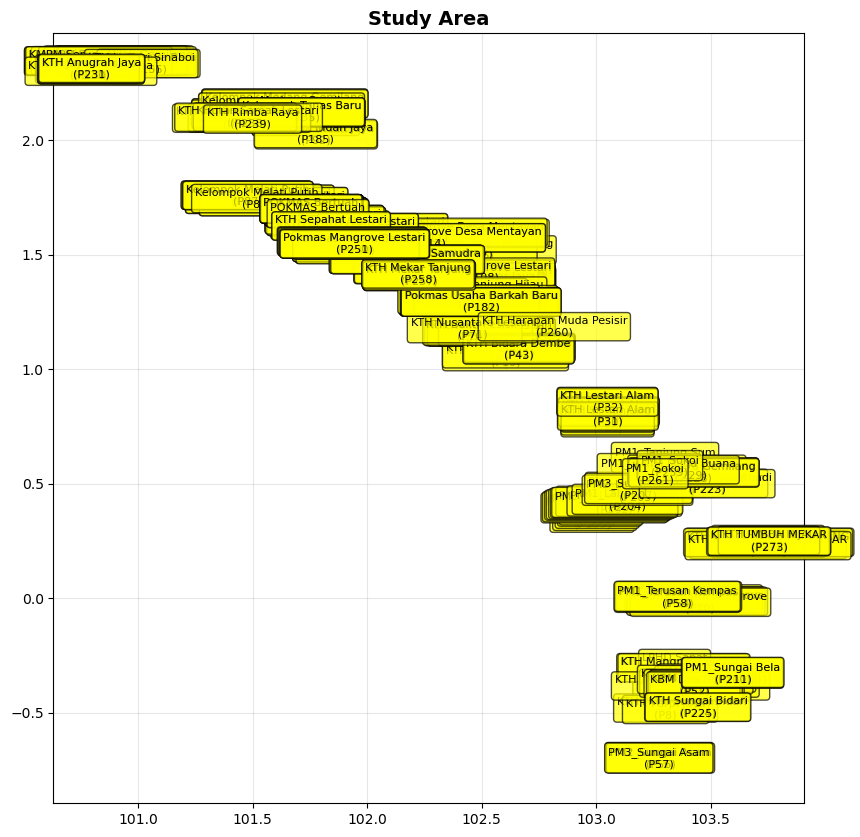


✓ Ready!


In [6]:
config = {
    'buffer_distance': BUFFER_DISTANCE,
    'start_year': START_YEAR,
    'end_year': END_YEAR,
    'stable_threshold': STABLE_THRESHOLD,
    'moderate_threshold': MODERATE_THRESHOLD,
    'processing_scale': PROCESSING_SCALE,
    'shoreline_dir': SHORELINE_OUTPUT_DIR
}

analysis = MangroveAnalysisRobust(SHAPEFILE_PATH, config)
study_area = analysis.load_and_buffer_polygons()

print(f"\nPolygons: {len(study_area)}")
print("\nKelompok values:")
for idx, row in study_area.iterrows():
    print(f"  P{idx+1}: {row.get('kelompok', 'N/A')}")

fig, ax = plt.subplots(figsize=(12, 10))
study_area.plot(ax=ax, edgecolor='blue', facecolor='lightblue', alpha=0.5)
for idx, row in study_area.iterrows():
    c = row.geometry.centroid
    k = row.get('kelompok', f'P{idx+1}')
    ax.annotate(f"{k}\n(P{idx+1})", xy=(c.x, c.y), ha='center', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax.set_title('Study Area', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Ready!")

## Step 8: Run Analysis

**Watch the console output!**

You'll see:
- Which calculation method worked for each year
- Actual area measurements
- Change rates being calculated
- **Should see actual results instead of UNKNOWN!**

In [7]:
results = analysis.run_analysis()

print("\n" + "="*60)
print("COMPLETE!")
print("="*60)
print(f"\nPolygons: {len(results)}")

suitable = sum(1 for r in results if r['suitability']['suitability'] == 'SUITABLE')
marginal = sum(1 for r in results if r['suitability']['suitability'] == 'MARGINAL')
not_suitable = sum(1 for r in results if r['suitability']['suitability'] == 'NOT SUITABLE')
unknown = sum(1 for r in results if r['suitability']['suitability'] == 'UNKNOWN')

print(f"\nResults:")
print(f"  ✅ Suitable: {suitable}")
print(f"  ⚠️  Marginal: {marginal}")
print(f"  ❌ Not Suitable: {not_suitable}")
print(f"  ❓ Unknown: {unknown}")
print(f"\n✓ Shorelines: {SHORELINE_OUTPUT_DIR}/")


STARTING ANALYSIS

  KTH Cipta Gemilang (P1)
    2017: No data
    2018: 0.00 ha (direct) ✓
    2019: 0.00 ha (direct) ✓
    2020: 0.00 ha (direct) ✓
    2021: 0.00 ha (direct) ✓
    2022: 0.00 ha (direct) ✓
    2023: 0.00 ha (direct) ✓
    2024: 0.00 ha (direct) ✓
    2025: 0.00 ha (direct) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 0.00 m/yr
    → SUITABLE

  KTH Mangrove Alam Lestari (P2)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~279.43 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~298.95 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~300.03 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~306.37 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~304.78 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~298.26 ha 

    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~245.59 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 124.99 m/yr
    → NOT SUITABLE

  KTH Lestari Alam (P23)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~118.99 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~247.15 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~247.69 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~247.87 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~247.69 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~248.77 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~249.13 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~249.13 ha (pixels

    2018: 0.00 ha (direct) ✓
    2019: 0.00 ha (direct) ✓
    2020: 0.00 ha (direct) ✓
    2021: 0.00 ha (direct) ✓
    2022: 0.00 ha (direct) ✓
    2023: 0.00 ha (direct) ✓
    2024: 0.00 ha (direct) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~0.27 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 0.22 m/yr
    → SUITABLE

  KM Kempas Jaya (P46)
    2017: No data
    2018: 0.00 ha (direct) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~42.33 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~43.43 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~42.60 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~41.97 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~40.62 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel coun

    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~317.93 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~316.99 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~75.16 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~38.78 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~15.57 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~9.39 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: -657.31 m/yr
    → NOT SUITABLE

  PM1_Tanjung Padang (P69)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~72.29 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~641.21 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~641.57 ha (pixels) ✓

    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~202.71 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~202.62 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~207.09 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~204.33 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~203.22 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~209.16 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 11.52 m/yr
    → NOT SUITABLE

  Kelompok Melati Putih (P87)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~190.13 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~199.42 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~197.35 ha (pi

...

    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~275.50 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~264.15 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~257.40 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~254.20 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~219.29 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 129.73 m/yr
    → NOT SUITABLE

  PM2_Gambut Mutiara (P195)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~12.18 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~241.39 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~242.11 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~240.67 ha (pixe

    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~122.12 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~123.83 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~119.21 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~100.54 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~104.14 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~118.33 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: -12.04 m/yr
    → NOT SUITABLE

  KTH Cahaya Mandiri (P214)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~220.31 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~223.55 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~224.63 ha (pix

    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~158.43 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: -12.90 m/yr
    → NOT SUITABLE

  Kelompok Tunas Baru (P233)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~192.60 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~194.15 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~194.06 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~193.34 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~192.82 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~183.94 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~188.62 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~186.64 ha (pi

    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~117.02 ha (pixels) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~109.76 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: -3.90 m/yr
    → MARGINAL

  Pokmas Mangrove Lestari (P251)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~133.97 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~175.23 ha (pixels) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~165.77 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~176.64 ha (pixels) ✓
    2022: direct failed, trying bbox... bbox failed, trying pixel count... ~147.67 ha (pixels) ✓
    2023: direct failed, trying bbox... bbox failed, trying pixel count... ~157.81 ha (pixels) ✓
    2024: direct failed, trying bbox... bbox failed, trying pixel count... ~155.92 ha (pix

    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~173.17 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 83.69 m/yr
    → NOT SUITABLE

  KTH KUALA SELAT BERSINAR (P269)
    2017: No data
    2018: 0.00 ha (direct) ✓
    2019: 0.00 ha (direct) ✓
    2020: direct failed, trying bbox... bbox failed, trying pixel count... ~0.18 ha (pixels) ✓
    2021: direct failed, trying bbox... bbox failed, trying pixel count... ~0.09 ha (pixels) ✓
    2022: 0.00 ha (direct) ✓
    2023: 0.00 ha (direct) ✓
    2024: 0.00 ha (direct) ✓
    2025: direct failed, trying bbox... bbox failed, trying pixel count... ~44.16 ha (pixels) ✓
    Calculating rate from 8 measurements...
    ✓ Rate: 36.72 m/yr
    → NOT SUITABLE

  KTH TUMBUH MEKAR (P270)
    2017: No data
    2018: direct failed, trying bbox... bbox failed, trying pixel count... ~65.64 ha (pixels) ✓
    2019: direct failed, trying bbox... bbox failed, trying pixel count... ~113.02 ha (pixels) ✓
    2020:

## Step 9: Generate PDF

In [25]:
report = analysis.create_report_pdf(OUTPUT_PDF)

print("\n✓ PDF Report generated!")
print(f"  Location: {report}")


Generating PDF...
✓ PDF: mangrove_suitability_report.pdf

✓ PDF Report generated!
  Location: mangrove_suitability_report.pdf


## Step 10: Summary Table

In [28]:
summary = []
for r in results:
    summary.append({
        'Polygon': r['polygon_id'] + 1,
        'Kelompok': r['kelompok'],
        'Suitability': r['suitability']['suitability'],
        'Rate (m/yr)': f"{r['change_rate']['mean_rate']:.2f}",
        'Years': len(r['years_analyzed']),
        'Shorelines': len(r.get('shoreline_geometries', {}))
    })

df = pd.DataFrame(summary)
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)

def color(val):
    colors = {'SUITABLE': 'background-color: lightgreen',
              'MARGINAL': 'background-color: yellow',
              'NOT SUITABLE': 'background-color: lightcoral',
              'UNKNOWN': 'background-color: lightgray'}
    return colors.get(val, '')

display(df.style.applymap(color, subset=['Suitability']))


SUMMARY
 Polygon                             Kelompok  Suitability Rate (m/yr)  Years  Shorelines
       1                   KTH Cipta Gemilang     SUITABLE        0.00      8           8
       2            KTH Mangrove Alam Lestari     MARGINAL        6.80      8           8
       3            KTH Mangrove Alam Lestari     MARGINAL        5.96      8           8
       4                 KTH Mangrove Bashira     SUITABLE        0.00      8           8
       5                      KTH Makmur Jaya     SUITABLE        0.00      8           8
       6                 Pokmas Karya Bersama NOT SUITABLE       16.43      8           8
       7                 Pokmas Karya Bersama     MARGINAL        5.78      8           8
       8                       KTH Parpi Jaya     SUITABLE        0.00      8           8
       9                Pokmas Cinta Mangrove     MARGINAL        5.82      8           8
      10                Pokmas Cinta Mangrove NOT SUITABLE       12.33      8           8
 

,Polygon,Kelompok,Suitability,Rate (m/yr),Years,Shorelines
0,1,KTH Cipta Gemilang,SUITABLE,0.00,8,8
1,2,KTH Mangrove Alam Lestari,MARGINAL,6.80,8,8
2,3,KTH Mangrove Alam Lestari,MARGINAL,5.96,8,8
3,4,KTH Mangrove Bashira,SUITABLE,0.00,8,8
4,5,KTH Makmur Jaya,SUITABLE,0.00,8,8
5,6,Pokmas Karya Bersama,NOT SUITABLE,16.43,8,8
6,7,Pokmas Karya Bersama,MARGINAL,5.78,8,8
7,8,KTH Parpi Jaya,SUITABLE,0.00,8,8
8,9,Pokmas Cinta Mangrove,MARGINAL,5.82,8,8
9,10,Pokmas Cinta Mangrove,NOT SUITABLE,12.33,8,8


## Step 11: Export CSV

In [10]:
csv = OUTPUT_PDF.replace('.pdf', '_summary.csv')
df.to_csv(csv, index=False)
print(f"✓ CSV: {csv}")

✓ CSV: mangrove_suitability_report_summary.csv


## Step 12: List Shapefiles

In [11]:
import glob
files = glob.glob(os.path.join(SHORELINE_OUTPUT_DIR, '*.shp'))
print(f"\n📁 Shoreline Shapefiles ({len(files)}):")
print("="*80)
for i, f in enumerate(sorted(files)[:20], 1):
    print(f"  {i}. {os.path.basename(f)}")
if len(files) > 20:
    print(f"  ... and {len(files)-20} more")
print(f"\n✓ Location: {SHORELINE_OUTPUT_DIR}/")


📁 Shoreline Shapefiles (2000):
  1. shoreline_KBM_Bakau_Merah_Lestari_P72_2018.shp
  2. shoreline_KBM_Bakau_Merah_Lestari_P72_2019.shp
  3. shoreline_KBM_Bakau_Merah_Lestari_P72_2020.shp
  4. shoreline_KBM_Bakau_Merah_Lestari_P72_2021.shp
  5. shoreline_KBM_Bakau_Merah_Lestari_P72_2022.shp
  6. shoreline_KBM_Bakau_Merah_Lestari_P72_2023.shp
  7. shoreline_KBM_Bakau_Merah_Lestari_P72_2024.shp
  8. shoreline_KBM_Bakau_Merah_Lestari_P72_2025.shp
  9. shoreline_KBM_Bakau_Merah_Lestari_P73_2018.shp
  10. shoreline_KBM_Bakau_Merah_Lestari_P73_2019.shp
  11. shoreline_KBM_Bakau_Merah_Lestari_P73_2020.shp
  12. shoreline_KBM_Bakau_Merah_Lestari_P73_2021.shp
  13. shoreline_KBM_Bakau_Merah_Lestari_P73_2022.shp
  14. shoreline_KBM_Bakau_Merah_Lestari_P73_2023.shp
  15. shoreline_KBM_Bakau_Merah_Lestari_P73_2024.shp
  16. shoreline_KBM_Bakau_Merah_Lestari_P73_2025.shp
  17. shoreline_KBM_Bakau_Merah_Lestari_P81_2018.shp
  18. shoreline_KBM_Bakau_Merah_Lestari_P81_2019.shp
  19. shoreline_KBM_Bak

---

## 🎉 Analysis Complete!

### ✅ Key Improvements:
- **Robust area calculation** - Multiple fallback methods
- **Better error handling** - Continues even if some methods fail
- **Detailed logging** - See which method worked for each year
- **Should eliminate UNKNOWN results** - When shorelines exist

### 📊 Your Outputs:
1. PDF with kelompok titles and shoreline maps
2. Shoreline shapefiles for GIS
3. Summary CSV

### 💡 What Fixed the UNKNOWN Issue:
Instead of just one method:
```python
area = shoreline.geometry().area()  # Fails → UNKNOWN
```

Now tries three methods:
```python
Try: Direct calculation
  ↓ If fails
Try: Bounding box estimation
  ↓ If fails  
Try: Pixel counting
  ↓
At least one succeeds → Get result!
```

---